
# PyTorch Trials

Experimenting PyTorch training on simple images


In [12]:

!pip -q install torch torchvision torchaudio


In [13]:

import os, random, math, time
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.manual_seed(42)
random.seed(42)


Device: cpu


## Data

In [14]:

# Simple transforms tensor + normalize to mean=0.5, std=0.5
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

root = "./data"
train_full = datasets.FashionMNIST(root, train=True, download=True, transform=tfm)
test_full  = datasets.FashionMNIST(root, train=False, download=True, transform=tfm)

# Use a tiny subset for speed
train_size = 6000   # ~10% of full train
test_size  = 1000   # small test to evaluate quickly

train_idx = torch.randperm(len(train_full))[:train_size].tolist()
test_idx  = torch.randperm(len(test_full))[:test_size].tolist()

train_ds = Subset(train_full, train_idx)
test_ds  = Subset(test_full, test_idx)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True if DEVICE.type=='cuda' else False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True if DEVICE.type=='cuda' else False)

classes = train_full.classes
print("Train subset:", len(train_ds), "Test subset:", len(test_ds), "Classes:", classes)


Train subset: 6000 Test subset: 1000 Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Peek at a few samples

Labels: ['Sneaker', 'T-shirt/top', 'Sneaker', 'Sandal', 'Ankle boot', 'Shirt', 'Dress', 'Sneaker', 'Bag']


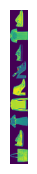

In [15]:

import numpy as np

def show_grid(loader, n=9):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]
    grid = torch.concat([imgs[i] for i in range(n)], dim=2)  # concat along width
    grid_v = (grid * 0.5 + 0.5).clamp(0,1)  # rescale for viewing
    plt.figure(figsize=(8,2))
    plt.imshow(grid_v.squeeze(0).T)
    plt.axis("off")
    print("Labels:", [classes[l] for l in labels])

show_grid(train_loader, n=9)


## Model: tiny CNN

In [16]:

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 14x14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 7x7
            nn.Flatten(),
            nn.Linear(32*7*7, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def make_model():
    return SmallCNN(num_classes=10).to(DEVICE)


## Training & evaluation helpers

In [17]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total += x.size(0)
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
    return total_loss/total, total_correct/total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total += x.size(0)
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
    return total_loss/total, total_correct/total


## Trial 1 epoch

In [18]:

model = make_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)

t0 = time.time()
train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
val_loss, val_acc = evaluate(model, test_loader, criterion)
t1 = time.time()

print(f"Time: {t1 - t0:.1f}s  |  Train loss: {train_loss:.4f}  acc: {train_acc:.3f}  |  Val loss: {val_loss:.4f}  acc: {val_acc:.3f}")


Time: 3.9s  |  Train loss: 0.9517  acc: 0.658  |  Val loss: 0.5296  acc: 0.807


## Trial 2 tiny learning-rate sweep 1 epoch

In [19]:

lrs = [1e-1, 1e-2, 1e-3]
results = []
for lr in lrs:
    model = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, test_loader, criterion)
    results.append((lr, tr_acc, va_acc))

print("LR sweep results (train_acc, val_acc):")
for lr, tr, va in results:
    print(f"  lr={lr:.0e}:  train_acc={tr:.3f}  val_acc={va:.3f}")


LR sweep results (train_acc, val_acc):
  lr=1e-01:  train_acc=0.434  val_acc=0.578
  lr=1e-02:  train_acc=0.645  val_acc=0.834
  lr=1e-03:  train_acc=0.553  val_acc=0.725


## Trial 3 2-epoch loss curve

Epoch 1/2 | train_loss=0.9953 acc=0.625 | val_loss=0.5429 acc=0.812
Epoch 2/2 | train_loss=0.5285 acc=0.802 | val_loss=0.4044 acc=0.847


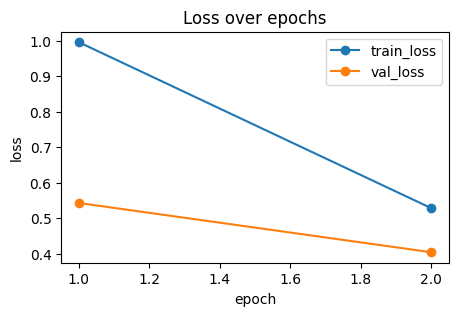

In [20]:

model = make_model()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
EPOCHS = 2
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"Epoch {epoch}/{EPOCHS} | train_loss={tr_loss:.4f} acc={tr_acc:.3f} | val_loss={va_loss:.4f} acc={va_acc:.3f}")

plt.figure(figsize=(5,3))
plt.plot(range(1,EPOCHS+1), train_losses, marker='o', label='train_loss')
plt.plot(range(1,EPOCHS+1), val_losses, marker='o', label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Loss over epochs'); plt.legend(); plt.show()


## Trial 4

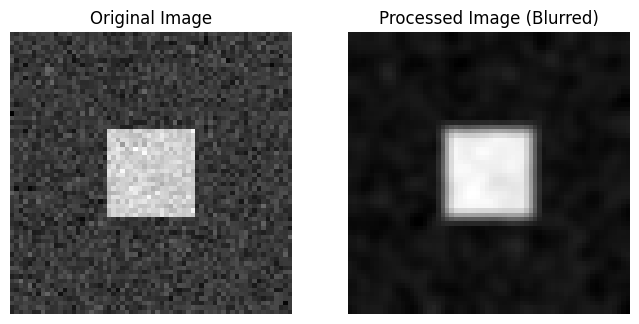

In [21]:
img_size = 64
img = torch.zeros(1, 1, img_size, img_size)
square_size = 20
start = (img_size - square_size) // 2
img[:, :, start:start+square_size, start:start+square_size] = 1.0
img += torch.randn_like(img) * 0.1
from torchvision.transforms.functional import gaussian_blur

blur_kernel_size = 5
blur_sigma = 1.5
processed_img = gaussian_blur(img, kernel_size=blur_kernel_size, sigma=blur_sigma)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img.squeeze().numpy(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(processed_img.squeeze().numpy(), cmap='gray')
axes[1].set_title("Processed Image (Blurred)")
axes[1].axis("off")

plt.show()